In [1]:
"""
v6_durable_checkpoint.py
--------------------------
A LangGraph pipeline that reads a free-format MT599 SWIFT settlement message
(which may contain one or more distinct instructions -- cancellations,
creations, amendments -- mixed together in plain text) and produces ONE
structured JSON output: a list of instructions, each tagged with its type
and validated against type-specific required fields.

This file is self-contained: schema, LLM setup, prompt, graph nodes, graph
build, visualization, and a test demonstration. It does not depend on any
other file.

Pipeline, in plain English (unchanged from the previous version):

    1. EXTRACT       -- one LLM call reads the whole message and returns
                        EVERY instruction found in it. RetryPolicy handles
                        TRANSIENT failures automatically; a manual fallback
                        handles DETERMINISTIC failures by switching
                        extraction strategy.

    2. DISPATCH (Send) -- a routing function returns a LIST of Send(...)
                        objects, one per instruction, so validation runs
                        for every instruction IN PARALLEL, in one
                        "superstep."

    3. VALIDATE       -- each parallel branch checks required fields with
                        plain Python. Results merge via a REDUCER.

    4. HUMAN REVIEW   -- (DYNAMIC interrupt) if any instruction is missing
                        a required field that was never in the message
                        text, the graph pauses and asks a human to supply
                        it. Skipped entirely if nothing is missing.

    5. FINALIZE       -- assembles the final {"instructions": [...]} JSON.

WHAT'S NEW IN THIS VERSION:

    A. DURABLE CHECKPOINTING -- every previous version used InMemorySaver,
       which keeps paused graph state ONLY in this process's memory. If the
       process restarts (a server redeploys, a script crashes) while a
       thread is paused, that state is gone forever. This version uses
       AsyncSqliteSaver instead, which writes checkpoints to an actual
       SQLite file on disk -- a paused thread survives a full process
       restart, as the demo below proves directly rather than just
       asserting it.

    B. STATIC INTERRUPTS -- compiled with interrupt_before=["finalize"].
       Unlike the DYNAMIC interrupt() call inside human_review (which only
       pauses when the code decides something is actually missing), a
       static interrupt pauses EVERY SINGLE RUN, unconditionally, right
       before the named node -- no logic involved. This models a mandatory
       compliance checkpoint: "a person must sign off before the final JSON
       is emitted," regardless of whether validation found any problems.
"""

import os
import json
import uuid
import operator
from enum import Enum
from typing import Optional, List, Dict, Annotated, TypedDict

from pydantic import BaseModel, Field, ValidationError
from langchain_together import ChatTogether
from langgraph.graph import StateGraph
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langgraph.types import interrupt, Command, Send, RetryPolicy


# ---------------------------------------------------------------------------
# 1. STRUCTURED OUTPUT SCHEMA
# ---------------------------------------------------------------------------

class InstructionType(str, Enum):
    cancel = "cancel"
    create = "create"
    amend = "amend"
    unidentified = "unidentified"  # used when no operation could be found


class Instruction(BaseModel):
    """
    One settlement instruction extracted from the message. All non-type
    fields stay Optional[str] -- MT599 is free text, formats vary, and the
    receiving settlement system owns format validation, not us.
    """
    type: InstructionType = Field(
        description="The operation identified from the message text."
    )
    clientRef: Optional[str] = Field(
        default=None, description="Client reference for this instruction."
    )
    scRef: Optional[str] = Field(
        default=None, description="SC (settlement/system) reference, if present."
    )
    isin: Optional[str] = Field(
        default=None, description="ISIN of the security, if present."
    )
    qty: Optional[str] = Field(
        default=None, description="Quantity, captured exactly as written."
    )
    settlementDate: Optional[str] = Field(
        default=None, description="Settlement date, captured exactly as written."
    )
    sfkAccount: Optional[str] = Field(
        default=None, description="SFK account number, if present."
    )
    pset: Optional[str] = Field(
        default=None, description="Place of settlement, if present."
    )
    party: Optional[str] = Field(
        default=None, description="Party details, if present."
    )
    cpty: Optional[str] = Field(
        default=None, description="Counterparty details, if present."
    )
    remarks: Optional[str] = Field(
        default=None,
        description=(
            "Free-text notes explaining any problem with this instruction. "
            "Populated when type is 'unidentified', or when a required "
            "field is missing. Cleared if a human later supplies the "
            "missing value during review."
        ),
    )


class ExtractionResult(BaseModel):
    """
    Top-level shape returned by this pipeline. ALWAYS a list, ALWAYS
    non-empty -- one contract regardless of how many instructions (or none
    identifiable) the message contained.
    """
    instructions: List[Instruction] = Field(
        description=(
            "One or more instructions found in the message. If nothing "
            "could be identified, return exactly one instruction with "
            "type='unidentified' and an explanation in remarks."
        )
    )



C:\Users\Pandiyan\anaconda3\envs\langchain\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#%pip install langgraph-checkpoint-sqlite aiosqlite

In [3]:
from dotenv import load_dotenv
load_dotenv(".env")
# ---------------------------------------------------------------------------
# 2. LLM SETUP (Together AI via LangChain)
# ---------------------------------------------------------------------------

TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

structured_llm_json_schema = llm.with_structured_output(ExtractionResult, method="json_schema")


async def _manual_json_extract(prompt: str) -> ExtractionResult:
    """
    DETERMINISTIC-FAILURE fallback: prompts the raw `llm` for plain JSON
    text via `.ainvoke()` (no schema sent to the provider at all), then
    parses and validates the response ourselves.
    """
    manual_prompt = (
        prompt
        + "\n\nRespond with ONLY a single valid JSON object -- no markdown "
        "code fences, no explanation, no text before or after the JSON. "
        'The JSON must have this exact top-level shape: {"instructions": [...]}, '
        "where each item in the list has the fields described above."
    )
    response = await llm.ainvoke(manual_prompt)
    raw_text = response.content.strip()

    if raw_text.startswith("```"):
        raw_text = raw_text.strip("`")
        if raw_text.lower().startswith("json"):
            raw_text = raw_text[4:]
        raw_text = raw_text.strip()

    data = json.loads(raw_text)
    return ExtractionResult.model_validate(data)


In [4]:

# ---------------------------------------------------------------------------
# 3. PROMPT
# ---------------------------------------------------------------------------

EXTRACTION_PROMPT = """You are parsing a free-format MT599 SWIFT message used in trade settlement.

The message may contain ONE OR MORE distinct instructions (cancellation, creation, amendment),
mixed together in free text, in any order.

For EACH instruction you find, extract:
- type: cancel, create, amend, or unidentified
- clientRef, scRef, isin, qty, settlementDate, sfkAccount, pset, party, cpty
- remarks: only used to explain when type is "unidentified"

Rules:
1. Capture every field exactly as written in the message. Do NOT reformat dates,
   numbers, or reference codes.
2. If a field is not mentioned for an instruction, leave it null. Do not guess.
3. If you cannot identify ANY operation in the entire message, return exactly ONE
   instruction with type="unidentified" and a short explanation in remarks.
4. Return every instruction you find -- do not drop or merge separate instructions.

Message:
\"\"\"{message}\"\"\"
"""


In [5]:

# ---------------------------------------------------------------------------
# 4. REQUIRED FIELDS PER TYPE
# ---------------------------------------------------------------------------

REQUIRED_FIELDS_BY_TYPE: Dict[InstructionType, List[str]] = {
    InstructionType.cancel: ["clientRef"],
    InstructionType.create: ["clientRef", "isin", "qty", "sfkAccount"],
    InstructionType.amend: ["clientRef"],
    InstructionType.unidentified: [],
}


def _missing_fields(instruction: Instruction, required: List[str]) -> List[str]:
    missing = []
    for field_name in required:
        value = getattr(instruction, field_name)
        if value is None or str(value).strip() == "":
            missing.append(field_name)
    return missing


def _append_missing_note(instruction: Instruction, missing: List[str]) -> Instruction:
    if not missing:
        return instruction
    note = f"Missing required fields: {', '.join(missing)}"
    instruction.remarks = f"{instruction.remarks}; {note}" if instruction.remarks else note
    return instruction



In [6]:

# ---------------------------------------------------------------------------
# 5. GRAPH STATE
# ---------------------------------------------------------------------------

class SettlementState(TypedDict):
    raw_message: str

    all_instructions: List[Instruction]

    processed_instructions: Annotated[List[Instruction], operator.add]
    # Reducer required: multiple parallel validate_instruction branches
    # each write a single-item list here at the same time.

    result: Optional[ExtractionResult]
    error: Optional[str]


class InstructionValidationState(TypedDict):
    """State schema for the parallel validation branch only."""
    instruction_to_validate: Instruction



In [7]:

# ---------------------------------------------------------------------------
# 6. NODE: extract_instructions (async, with RetryPolicy at graph-build time)
# ---------------------------------------------------------------------------

async def extract_instructions(state: SettlementState) -> SettlementState:
    message = state["raw_message"]
    prompt = EXTRACTION_PROMPT.format(message=message)

    try:
        result = await structured_llm_json_schema.ainvoke(prompt)
    except (ValidationError, json.JSONDecodeError) as deterministic_error:
        result = await _fallback_after_deterministic_failure(prompt, deterministic_error)
    except Exception as e:
        if "grammar" in str(e).lower() or "schema" in str(e).lower():
            result = await _fallback_after_deterministic_failure(prompt, e)
        else:
            # Looks transient -- re-raise so RetryPolicy retries the WHOLE
            # node automatically, with backoff.
            raise

    state["all_instructions"] = result.instructions
    state["error"] = None
    return state


async def _fallback_after_deterministic_failure(prompt: str, original_error: Exception) -> ExtractionResult:
    try:
        return await _manual_json_extract(prompt)
    except Exception as fallback_error:
        return ExtractionResult(
            instructions=[
                Instruction(
                    type=InstructionType.unidentified,
                    remarks=(
                        f"Extraction failed. Preferred mode error: {original_error}. "
                        f"Fallback mode error: {fallback_error}."
                    ),
                )
            ]
        )


In [8]:

# ---------------------------------------------------------------------------
# 7. NODE: validate_instruction (the Send target)
# ---------------------------------------------------------------------------

def validate_instruction(state: InstructionValidationState) -> dict:
    instruction = state["instruction_to_validate"]
    required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
    missing = _missing_fields(instruction, required)
    instruction = _append_missing_note(instruction, missing)
    return {"processed_instructions": [instruction]}



In [9]:

# ---------------------------------------------------------------------------
# 8. DISPATCH FUNCTION (the Send fan-out)
# ---------------------------------------------------------------------------

def dispatch_to_validation(state: SettlementState) -> List[Send]:
    return [
        Send("validate_instruction", {"instruction_to_validate": instruction})
        for instruction in state["all_instructions"]
    ]


In [10]:

# ---------------------------------------------------------------------------
# 9. NODE: human_review (DYNAMIC interrupt -- only pauses if something is
#    actually missing)
# ---------------------------------------------------------------------------

def human_review(state: SettlementState) -> SettlementState:
    incomplete = []
    for index, instruction in enumerate(state["processed_instructions"]):
        required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
        missing = _missing_fields(instruction, required)
        if missing:
            incomplete.append({
                "index": index,
                "clientRef": instruction.clientRef,
                "type": instruction.type.value,
                "missing_fields": missing,
            })

    if not incomplete:
        return state  # nothing to review -- skip the pause entirely

    human_updates = interrupt({
        "message": (
            "The following instructions are missing required fields that "
            "were NOT present in the original MT599 message text. Supply "
            "values only if known from another source -- otherwise leave "
            "unresolved."
        ),
        "items": incomplete,
    })

    if human_updates:
        for index_str, field_updates in human_updates.items():
            instruction = state["processed_instructions"][int(index_str)]
            for field_name, value in field_updates.items():
                setattr(instruction, field_name, value)

    for item in incomplete:
        instruction = state["processed_instructions"][item["index"]]
        required = REQUIRED_FIELDS_BY_TYPE.get(instruction.type, [])
        still_missing = _missing_fields(instruction, required)
        instruction.remarks = (
            f"Missing required fields: {', '.join(still_missing)}"
            if still_missing else None
        )

    return state



In [11]:

# ---------------------------------------------------------------------------
# 10. NODE: finalize
#     A STATIC interrupt is configured at compile time (see section 12) to
#     ALWAYS pause right BEFORE this node runs -- every single invocation,
#     no exceptions, regardless of what human_review found. This node
#     itself has no idea an interrupt happens before it; the pause is
#     entirely a property of how the graph was compiled, not of this node's
#     own code.
# ---------------------------------------------------------------------------

def finalize(state: SettlementState) -> SettlementState:
    state["result"] = ExtractionResult(instructions=state["processed_instructions"])
    return state



In [12]:

# ---------------------------------------------------------------------------
# 11. BUILD THE GRAPH STRUCTURE (nodes + edges only -- NOT compiled yet)
#     Compilation is deferred to inside the demo function below, because
#     this version's whole point is to build the checkpointer/graph TWICE
#     -- once before a simulated restart, once after -- to prove state
#     survives. A module-level `graph` object wouldn't let us demonstrate
#     that, so `build_graph()` is a function instead of a single global.
# ---------------------------------------------------------------------------

def build_graph(checkpointer):
    builder = StateGraph(SettlementState)

    builder.add_node(
        "extract_instructions",
        extract_instructions,
        retry_policy=RetryPolicy(max_attempts=3, initial_interval=0.5, backoff_factor=2.0),
    )
    builder.add_node("validate_instruction", validate_instruction)
    builder.add_node("human_review", human_review)
    builder.add_node("finalize", finalize)

    builder.set_entry_point("extract_instructions")
    builder.add_conditional_edges("extract_instructions", dispatch_to_validation, ["validate_instruction"])
    builder.add_edge("validate_instruction", "human_review")
    builder.add_edge("human_review", "finalize")
    builder.set_finish_point("finalize")

    # interrupt_before=["finalize"]: a STATIC interrupt. Unlike the dynamic
    # interrupt() inside human_review, this pauses EVERY run, unconditionally,
    # right before finalize -- no code decides whether to pause here, the
    # compile-time configuration decides for every run.
    return builder.compile(checkpointer=checkpointer, interrupt_before=["finalize"])


def visualize_graph(compiled_graph, output_path: str = "graph_v6.png") -> None:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass

    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")




In [13]:

# ---------------------------------------------------------------------------
# 12. DEMO -- durability across a simulated process restart, then the
#     static interrupt before finalize.
#
#     Sequence:
#       PHASE 1 -- open a fresh SQLite checkpoint file, build graph #1, run
#                  a message that's missing a required field. The dynamic
#                  interrupt() in human_review fires -- graph pauses.
#       "RESTART" -- close graph #1's checkpointer connection completely
#                  and delete the Python objects, simulating the process
#                  exiting. Nothing is kept in memory across this point.
#       PHASE 2 -- open a BRAND NEW connection to the SAME SQLite file,
#                  build a completely new graph #2 from it, and prove the
#                  paused state is still readable -- this is the actual
#                  durability check, not an assumption.
#       PHASE 3 -- resume graph #2 with the human-supplied correction. This
#                  clears the dynamic interrupt, but immediately hits the
#                  STATIC interrupt before finalize -- a mandatory pause
#                  that would happen even if nothing had been missing.
#       PHASE 4 -- "approve" the static interrupt by resuming with `None`
#                  as input (the correct way to continue past a static
#                  interrupt -- there's no value being awaited here, just a
#                  fixed gate to release).
# ---------------------------------------------------------------------------

DB_PATH = "mt599_checkpoints.sqlite"


async def demo_durable_checkpoint():
    # Start clean so this demo is repeatable.
    if os.path.exists(DB_PATH):
        os.remove(DB_PATH)

    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}

    sample_message = (
        "Please cancel the trade has client reference XYZABC, "
        "Also create a new trade with client reference QWERTY, "
        "it should have the ISIN DFGHISIN, Qty=100. "
        "Also amend trade with client reference AMEND001, change settlement date to 5th July."
    )
    initial_state = {
        "raw_message": sample_message,
        "all_instructions": [],
        "processed_instructions": [],
        "result": None,
        "error": None,
    }

    # ---- PHASE 1: run until the dynamic interrupt (human_review) fires ----
    print("\n" + "=" * 70)
    print("PHASE 1: running graph #1 -- expect a pause in human_review")
    print("=" * 70)

    async with AsyncSqliteSaver.from_conn_string(DB_PATH) as checkpointer_1:
        graph_1 = build_graph(checkpointer_1)
        visualize_graph(graph_1)

        first_pass = await graph_1.ainvoke(initial_state, config)
        assert "__interrupt__" in first_pass, "Expected a pause in human_review"
        payload = first_pass["__interrupt__"][0].value
        print("Paused. Missing fields:")
        print(json.dumps(payload["items"], indent=2))
    # `async with` exits here -- the SQLite connection for graph_1 is fully
    # closed. graph_1 and checkpointer_1 are about to go out of scope too.

    print("\n[simulating a process restart -- graph_1/checkpointer_1 are gone]")
    del graph_1, checkpointer_1

    # ---- PHASE 2: brand-new connection, brand-new graph, same file -------
    print("\n" + "=" * 70)
    print("PHASE 2: opening a NEW connection to the SAME sqlite file")
    print("=" * 70)

    async with AsyncSqliteSaver.from_conn_string(DB_PATH) as checkpointer_2:
        graph_2 = build_graph(checkpointer_2)

        # THIS is the actual durability proof: graph_2 has never seen this
        # thread_id in memory -- everything it knows about it comes from
        # the SQLite file that survived the "restart" above.
        state_snapshot = await graph_2.aget_state(config)
        still_paused = any(task.interrupts for task in state_snapshot.tasks)
        print(f"State recovered from disk. Still paused: {still_paused}")
        print(f"processed_instructions so far: "
              f"{[i.clientRef for i in state_snapshot.values['processed_instructions']]}")

        # ---- PHASE 3: resume the dynamic interrupt ------------------------
        print("\n" + "=" * 70)
        print("PHASE 3: resuming human_review with a human-supplied value")
        print("=" * 70)

        human_supplied_updates = {"1": {"sfkAccount": "5678"}}  # looked up externally
        second_pass = await graph_2.ainvoke(Command(resume=human_supplied_updates), config)

        # human_review's dynamic interrupt is now resolved, but we should be
        # paused again -- this time at the STATIC interrupt_before=["finalize"].
        state_snapshot = await graph_2.aget_state(config)
        print(f"Next node(s) queued to run: {state_snapshot.next}")
        assert state_snapshot.next == ("finalize",), "Expected the static interrupt before finalize"
        print("Confirmed: paused before 'finalize' due to the STATIC interrupt "
              "(interrupt_before=['finalize']) -- this happens on EVERY run.")

        # ---- PHASE 4: approve the static interrupt ------------------------
        print("\n" + "=" * 70)
        print("PHASE 4: approving the static interrupt (resume with None)")
        print("=" * 70)

        # Resuming past a STATIC interrupt uses `None` as the input, not
        # Command(resume=...) -- there's no interrupt() call inside
        # finalize waiting for a value; the pause is purely a compile-time
        # gate, and `None` means "proceed as if nothing happened."
        final_state = await graph_2.ainvoke(None, config)

    print("\n--- Final result ---")
    print(json.dumps(final_state["result"].model_dump(), indent=2))


if __name__ == "__main__":
    import asyncio
    try:
        asyncio.get_running_loop()
        print(
            "A running event loop was detected (this is normal inside "
            "Jupyter/IPython).\n"
            "Run this directly in a notebook cell instead:\n\n"
            "    await demo_durable_checkpoint()\n"
        )
    except RuntimeError:
        asyncio.run(demo_durable_checkpoint())


A running event loop was detected (this is normal inside Jupyter/IPython).
Run this directly in a notebook cell instead:

    await demo_durable_checkpoint()




PHASE 1: running graph #1 -- expect a pause in human_review


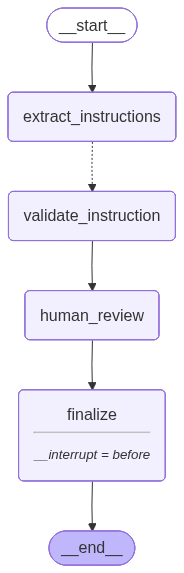

Deserializing unregistered type __main__.InstructionType from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'InstructionType')]
Deserializing unregistered type __main__.Instruction from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Instruction')]


Paused. Missing fields:
[
  {
    "index": 1,
    "clientRef": "QWERTY",
    "type": "create",
    "missing_fields": [
      "sfkAccount"
    ]
  }
]

[simulating a process restart -- graph_1/checkpointer_1 are gone]

PHASE 2: opening a NEW connection to the SAME sqlite file
State recovered from disk. Still paused: True
processed_instructions so far: ['XYZABC', 'QWERTY', 'AMEND001']

PHASE 3: resuming human_review with a human-supplied value
Next node(s) queued to run: ('finalize',)
Confirmed: paused before 'finalize' due to the STATIC interrupt (interrupt_before=['finalize']) -- this happens on EVERY run.

PHASE 4: approving the static interrupt (resume with None)

--- Final result ---
{
  "instructions": [
    {
      "type": "cancel",
      "clientRef": "XYZABC",
      "scRef": null,
      "isin": null,
      "qty": null,
      "settlementDate": null,
      "sfkAccount": null,
      "pset": null,
      "party": null,
      "cpty": null,
      "remarks": null
    },
    {
      "type

In [27]:
await demo_durable_checkpoint()